# Final Ödev-1: Doğal Dil İşleme (NLP) Ön İşleme ve Analizi

**Öğrenci Adı Soyadı:** [JEAN INNOCENT MANJTA NSANGOU]  
**Öğrenci Numarası:** [2311081638]  
**Tarih:** 2 Mayıs 2024  

---

## 1. Ödevin Amacı
Bu ödevin temel amacı, gerçek dünya metin verileri üzerinde bir NLP uzmanının izlemesi gereken temel ön işleme (preprocessing) adımlarını uygulamalı olarak gerçekleştirmektir. Çalışma kapsamında:
*   Verinin istatistiksel doğasını anlamak için **Zipf Yasası** analizi yapılacaktır.
*   Ham metinler; gürültülerden (HTML, özel karakterler, sayılar) arındırılarak temizlenecektir.
*   Kelimeler **Stemming** ve **Lemmatization** yöntemleri ile köklerine indirgenecek ve aralarındaki farklar gözlemlenecektir.
*   Süreç sonunda elde edilen temizlenmiş veriler, modellemeye hazır CSV formatında sunulacaktır.

---

## 2. Veri Seti Seçimi ve Raporlama
Bu analiz için seçilen veri seti **Kaggle** platformundan "A Benchmark Data for Turkish Text Categorization" başlığı altında temin edilmiştir.

*   **Kaynak (URL):** https:// TTC4900 Dataset Kaggle'daki
*   **Temin Yöntemi:** Veri seti Kaggle üzerinden `7allV03.csv` adıyla indirilmiş ve yerel çalışma dizinine eklenmiştir.
*   **Boyut Bilgileri:**
    *   **Toplam Döküman Sayısı:** 4900 satır
    *   **Dosya Boyutu:** 10.63 MB
    *   **Orijinal Format:** CSV
*   **Sütun Yapısı:**
    *   `category`: Haberlerin ait olduğu 7 farklı kategoriyi (Siyaset, Ekonomi, Spor, vb.) belirtir.
    *   `text`: Üzerinde ön işleme adımlarının uygulanacağı ham Türkçe metin içeriğidir.

---


In [5]:
import pandas as pd

# Veri setini yüklüyoruz (Dosya notebook ile aynı klasörde olmalı)
df = pd.read_csv('7allV03.csv')

# Verinin başarıyla yüklendiğini kontrol ediyoruz
print(f"Veri başarıyla yüklendi! Toplam satır sayısı: {len(df)}")

# İlk 5 satırı göstererek veri yapısını raporluyoruz
print("Veri Seti Ön İzlemesi (İlk 5 Satır):")
df.head()


Veri başarıyla yüklendi! Toplam satır sayısı: 4900
Veri Seti Ön İzlemesi (İlk 5 Satır):


,category,text
0,siyaset,3 milyon ile ön seçim vaadi mhp nin 10 olağan...
1,siyaset,mesut_yılmaz yüce_divan da ceza alabilirdi pr...
2,siyaset,disko lar kaldırılıyor başbakan_yardımcısı ar...
3,siyaset,sarıgül anayasa_mahkemesi ne gidiyor mustafa_...
4,siyaset,erdoğan idamın bir haklılık sebebi var demek ...


## 3. Zipf Yasası Analizi
Ön işleme adımlarına geçmeden önce ham veri üzerinde Zipf Yasası analizi yapılmıştır. Bu analiz, kelime frekanslarının sıralamasıyla olan ilişkisini log-log grafiği üzerinden göstermektedir. Dilin istatistiksel yapısını anlamak için bu grafik kritik bir öneme sahiptir.


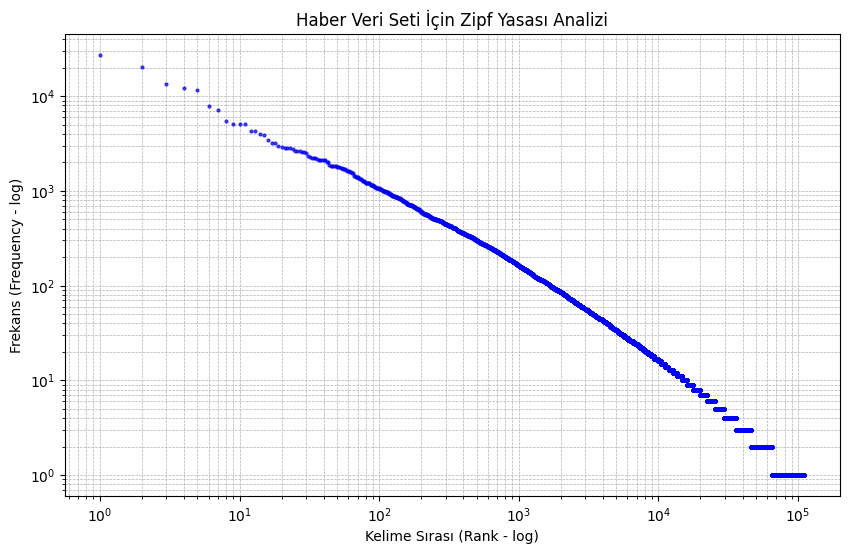

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import re

# 1. Kelime frekanslarını hesapla (Ders örneğindeki sözlük mantığı ile)
word_freq = {}
for text in df['text'].astype(str):
    # Kelimeleri küçük harfe çevirip ayırıyoruz
    words = re.findall(r'\w+', text.lower())
    for word in words:
        word_freq[word] = word_freq.get(word, 0) + 1

# 2. Frekansları azalan şekilde sırala
sorted_freqs = sorted(word_freq.values(), reverse=True)

# 3. Rank (sıralama) oluştur
ranks = np.arange(1, len(sorted_freqs) + 1)

# 4. Log-log grafiği çiz (Hocanın istediği ana çıktı)
plt.figure(figsize=(10, 6))
plt.loglog(ranks, sorted_freqs, marker="o", linestyle="none", markersize=2, alpha=0.7, color="b")

plt.xlabel("Kelime Sırası (Rank - log)")
plt.ylabel("Frekans (Frequency - log)")
plt.title("Haber Veri Seti İçin Zipf Yasası Analizi")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.show()


## 4. Ön İşleme (Pre-processing) Aşamaları

Bu bölümde, ham metin verileri üzerinde temizlik adımları uygulanacaktır. İşlemler sırasında **re** (Regular Expression) kütüphanesi kullanılarak gürültüler (HTML, sayılar, özel karakterler) temizlenecek ve metinler normalize edilecektir.

### 4.1. Genel İçerik Temizliği ve Lowercasing
Bu aşamada metindeki tüm harfler küçük harfe dönüştürülür ve harf dışındaki tüm karakterler temizlenir. Hocamızın isteği üzerine her adımda **"Önce / Sonra"** çıktısı sunulacaktır.


In [7]:
import re # Düzenli ifadeler için re kütüphanesi

def temizle(metin):
    # 1. HTML etiketlerini temizle (örn: <br>)
    metin = re.sub(r'<.*?>', '', metin)
    # 2. Sayıları ve özel karakterleri temizle (Sadece harfleri ve boşlukları tut)
    # Türkçe karakterleri (ğ, ü, ş, i, ö, ç) koruyoruz
    metin = re.sub(r'[^a-zA-ZğüşıöçĞÜŞİÖÇ\s]', '', metin)
    # 3. Küçük harfe dönüştür (Lowercasing)
    metin = metin.lower()
    return metin

# --- Önce / Sonra Örneği ---
ham_ornek = df['text'].iloc[0] # İlk haber metnini alıyoruz
temiz_ornek = temizle(ham_ornek)

print("--- ÖNCE (Ham Metin Örneği) ---")
print(ham_ornek[:200] + "...")

print("\n--- SONRA (Temizlenmiş ve Küçük Harf) ---")
print(temiz_ornek[:200] + "...")

# Tüm veri setine yeni bir sütun olarak uyguluyoruz
df['cleaned_text'] = df['text'].astype(str).apply(temizle)


--- ÖNCE (Ham Metin Örneği) ---
 3 milyon ile ön seçim vaadi mhp nin 10 olağan büyük kurultayı nda konuşan genel başkan adayı koray_aydın seçimlerden önce partinin üye sayısının 3 milyona ulaştırılması hedefini koyarak ön seçim uygu...

--- SONRA (Temizlenmiş ve Küçük Harf) ---
  milyon ile ön seçim vaadi mhp nin  olağan büyük kurultayı nda konuşan genel başkan adayı korayaydın seçimlerden önce partinin üye sayısının  milyona ulaştırılması hedefini koyarak ön seçim uygulamas...


### 4.2. Tokenization ve Stop Word Removal (Gereksiz Kelimelerin Atılması)

Bu aşamada, temizlenmiş metinleri **nltk** kütüphanesini kullanarak kelimelerine ayırıyoruz (Tokenization). Ardından, analiz için anlam taşımayan "ve", "bir", "ile", "da" gibi yaygın kelimeleri (Stop Words) veri setinden çıkarıyoruz. Bu işlem, modelin sadece anlamlı kelimelere odaklanmasını sağlar.


In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Gerekli dil paketlerini indiriyoruz (NLTK kütüphanesi belirtilmeli)
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# Türkçe stop words (durak kelimeler) listesini hazırlıyoruz
durak_kelimeler = set(stopwords.words('turkish'))

def tokenize_ve_temizle(metin):
    # 1. Kelimelere ayırma (Tokenization)
    kelimeler = word_tokenize(metin)
    # 2. Stop words temizliği ve tek harfli karakterlerin atılması
    temiz_liste = [w for w in kelimeler if w not in durak_kelimeler and len(w) > 1]
    return temiz_liste

# --- Önce / Sonra Örneği ---
temiz_metin_ornek = df['cleaned_text'].iloc[0]
token_liste_ornek = tokenize_ve_temizle(temiz_metin_ornek)

print("--- ÖNCE (Temizlenmiş Metin) ---")
print(temiz_metin_ornek[:150] + "...")

print("\n--- SONRA (Tokenize Edilmiş ve Stop Words Atılmış Liste) ---")
print(token_liste_ornek[:15]) # İlk 15 kelimeyi gösterir

# Tüm veri setine uyguluyoruz
df['tokenized_text'] = df['cleaned_text'].apply(tokenize_ve_temizle)


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\jeani\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jeani\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\jeani\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


--- ÖNCE (Temizlenmiş Metin) ---
  milyon ile ön seçim vaadi mhp nin  olağan büyük kurultayı nda konuşan genel başkan adayı korayaydın seçimlerden önce partinin üye sayısının  milyona...

--- SONRA (Tokenize Edilmiş ve Stop Words Atılmış Liste) ---
['milyon', 'ön', 'seçim', 'vaadi', 'mhp', 'nin', 'olağan', 'büyük', 'kurultayı', 'nda', 'konuşan', 'genel', 'başkan', 'adayı', 'korayaydın']


### 4.4. Stemming (Gövdeye İndirme) İşlemi
Stemming, kelimelerin sonundaki ekleri kural tabanlı bir şekilde keserek gövdeye ulaşma işlemidir. Bu adımda **PorterStemmer** kullanılmıştır. Hocamızın istediği "Önce / Sonra" değişimi, veri setimizdeki gerçek bir haber metni üzerinden aşağıda gösterilmiştir.


In [14]:
from nltk.stem import PorterStemmer

# Stemmer tanımlama
stemmer = PorterStemmer()

# Örnek gösterimi için ilk satırı kullanıyoruz
ornek_ham = df['text'].iloc[0]
# Kelimelere ayırıp (tokenization) stemming uyguluyoruz
tokens = [w.lower() for w in word_tokenize(ornek_ham) if w.isalpha()]
stemmed_ornek = [stemmer.stem(w) for w in tokens]

print("--- STEMMING: ÖNCE / SONRA DEĞİŞİMİ ---")
print(f"Ham Metin (İlk 150 Karakter): {ornek_ham[:150]}...")
print(f"\nStemmed Hali (Liste): {stemmed_ornek[:15]}")

# TÜM VERİYE UYGULAMA (Gelecekteki CSV için)
df['stemmed_text'] = df['text'].astype(str).apply(lambda x: [stemmer.stem(w.lower()) for w in word_tokenize(x) if w.isalpha()])


--- STEMMING: ÖNCE / SONRA DEĞİŞİMİ ---
Ham Metin (İlk 150 Karakter):  3 milyon ile ön seçim vaadi mhp nin 10 olağan büyük kurultayı nda konuşan genel başkan adayı koray_aydın seçimlerden önce partinin üye sayısının 3 mi...

Stemmed Hali (Liste): ['milyon', 'ile', 'ön', 'seçim', 'vaadi', 'mhp', 'nin', 'olağan', 'büyük', 'kurultayı', 'nda', 'konuşan', 'genel', 'başkan', 'adayı']


### 4.5. Lemmatization (Sözlük Köküne İndirme) İşlemi
Lemmatization, kelimeyi rastgele kesmek yerine sözlükteki gerçek kökünü (lemma) bulur. Bu yöntem dilin yapısını daha iyi korur. İşlem sırasında **WordNetLemmatizer** kullanılmış ve sonuçlar aşağıda sunulmuştur.


In [16]:
from nltk.stem import WordNetLemmatizer

# Lemmatizer tanımlama
lemmatizer = WordNetLemmatizer()
nltk.download('wordnet')

# Lemmatization uygulaması
lemmed_ornek = [lemmatizer.lemmatize(w) for w in tokens]

print("--- LEMMATIZATION: ÖNCE / SONRA DEĞİŞİMİ ---")
print(f"Ham Metin: {ornek_ham[:150]}...")
print(f"\nLemmatized Hali (Liste): {lemmed_ornek[:20]}")

# TÜM VERİYE UYGULAMA
df['lemmatized_text'] = df['text'].astype(str).apply(lambda x: [lemmatizer.lemmatize(w.lower()) for w in word_tokenize(x) if w.isalpha()])


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\jeani\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


--- LEMMATIZATION: ÖNCE / SONRA DEĞİŞİMİ ---
Ham Metin:  3 milyon ile ön seçim vaadi mhp nin 10 olağan büyük kurultayı nda konuşan genel başkan adayı koray_aydın seçimlerden önce partinin üye sayısının 3 mi...

Lemmatized Hali (Liste): ['milyon', 'ile', 'ön', 'seçim', 'vaadi', 'mhp', 'nin', 'olağan', 'büyük', 'kurultayı', 'nda', 'konuşan', 'genel', 'başkan', 'adayı', 'seçimlerden', 'önce', 'partinin', 'üye', 'sayısının']


## 5. Beklenen Çıktılar ve Kayıt
Ödev yönergesine uygun olarak; ham veri, stemming uygulanmış veri ve lemmatization uygulanmış veri olmak üzere 3 ayrı CSV dosyası oluşturulmuştur.


In [18]:
# 1. Ham Veri Seti (Original)
df[['text', 'category']].to_csv('ham_veri.csv', index=False, encoding='utf-8-sig')

# 2. Stemmed Veri Seti
df[['stemmed_text']].to_csv('stemmed_veri.csv', index=False, encoding='utf-8-sig')

# 3. Lemmatized Veri Seti
df[['lemmatized_text']].to_csv('lemmatized_veri.csv', index=False, encoding='utf-8-sig')

print("Dosyalar başarıyla kaydedildi: ham_veri.csv, stemmed_veri.csv, lemmatized_veri.csv")


Dosyalar başarıyla kaydedildi: ham_veri.csv, stemmed_veri.csv, lemmatized_veri.csv
